# Ex 1

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [34]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 

## 1.

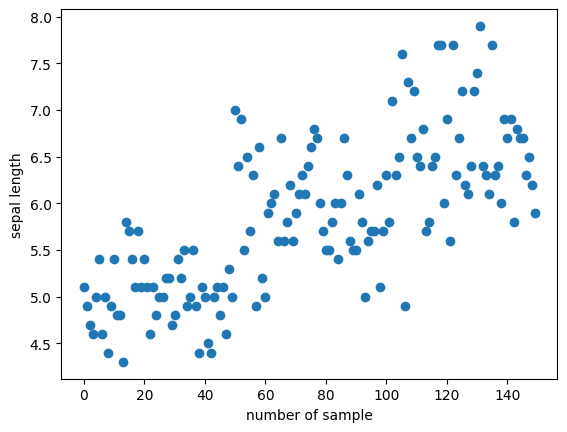

In [35]:
X_sepal_length = X["sepal length"]
samples = np.arange(0, len(X["sepal length"]), 1)
plt.scatter(samples, X_sepal_length)
plt.xlabel("number of sample")
plt.ylabel("sepal length")
plt.show()

Czy jest sens łączyć kropki na tym wykresie?
- Nie, bo dane są zbyt rozproszone, więc nie dostalibyśmy z łączenia kropek żadnej informacji 

## 2.

In [37]:
mask = y["class"] == "Iris-setosa"
sepal_width_setosa = X.loc[mask, "sepal width"]
print(sepal_width_setosa.shape) 

sepal_width_col = X["sepal width"]

lower_than_2p5 = sepal_width_col[sepal_width_col < 2.5]
between_2p5_3p0 = sepal_width_col[(sepal_width_col >= 2.5) & (sepal_width_col < 3.0)]
between_3p0_3p5 = sepal_width_col[(sepal_width_col >= 3.0) & (sepal_width_col < 3.5)]

(50,)


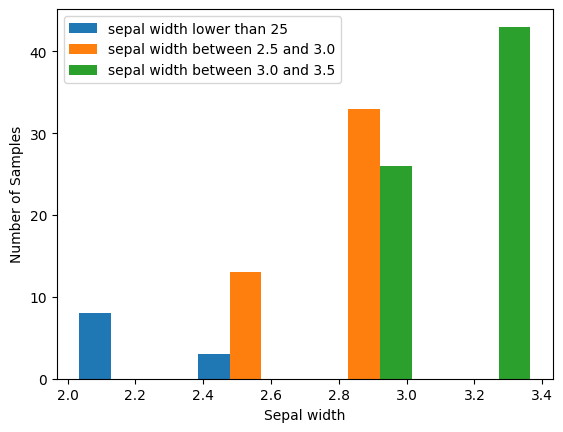

In [38]:
plt.hist(
    [lower_than_2p5, between_2p5_3p0, between_3p0_3p5],
    bins = 4,
    label=[
        "sepal width lower than 25",
        "sepal width between 2.5 and 3.0",
        "sepal width between 3.0 and 3.5",
    ]
)
plt.xlabel("Sepal width")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

## 3. 

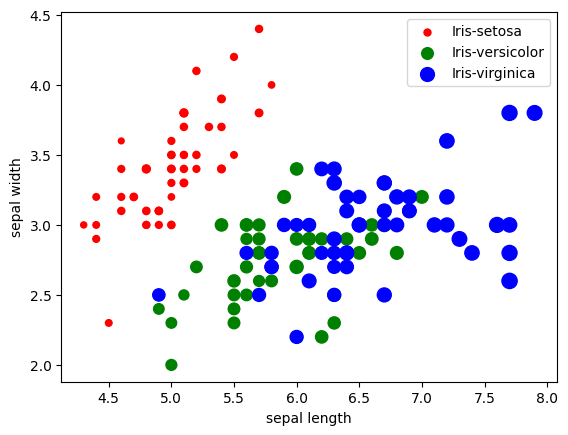

In [39]:
from matplotlib.colors import ListedColormap

colors = ["red", "green", "blue"]
classes = y["class"].unique()
my_cmap = ListedColormap(colors)

for i, class_name in enumerate(classes):
    mask = y["class"] == class_name
    data = {
        "x": X.loc[mask, "sepal length"],
        "y": X.loc[mask, "sepal width"],
        "color": colors[i],
        "dot_size": (X.loc[mask, "petal length"] / X["petal length"].max()) * 120,
    }
    plt.scatter(x="x", y="y", s="dot_size", c="color", label=class_name, data=data)

plt.xlabel("sepal length")
plt.ylabel("sepal width")
plt.legend()



plt.show()

Co ciekawego widać na tym wykresie? Czy potrafisz
wykorzystać wykres, żeby podać regułę odróżniania iris setosa od pozostałych dwóch gatunków
irysa?
- > Iris setosa odróżnia to, ma najmnieszy stosunek sepal lendth do sepal width z tych 3 gatunków

## 4.

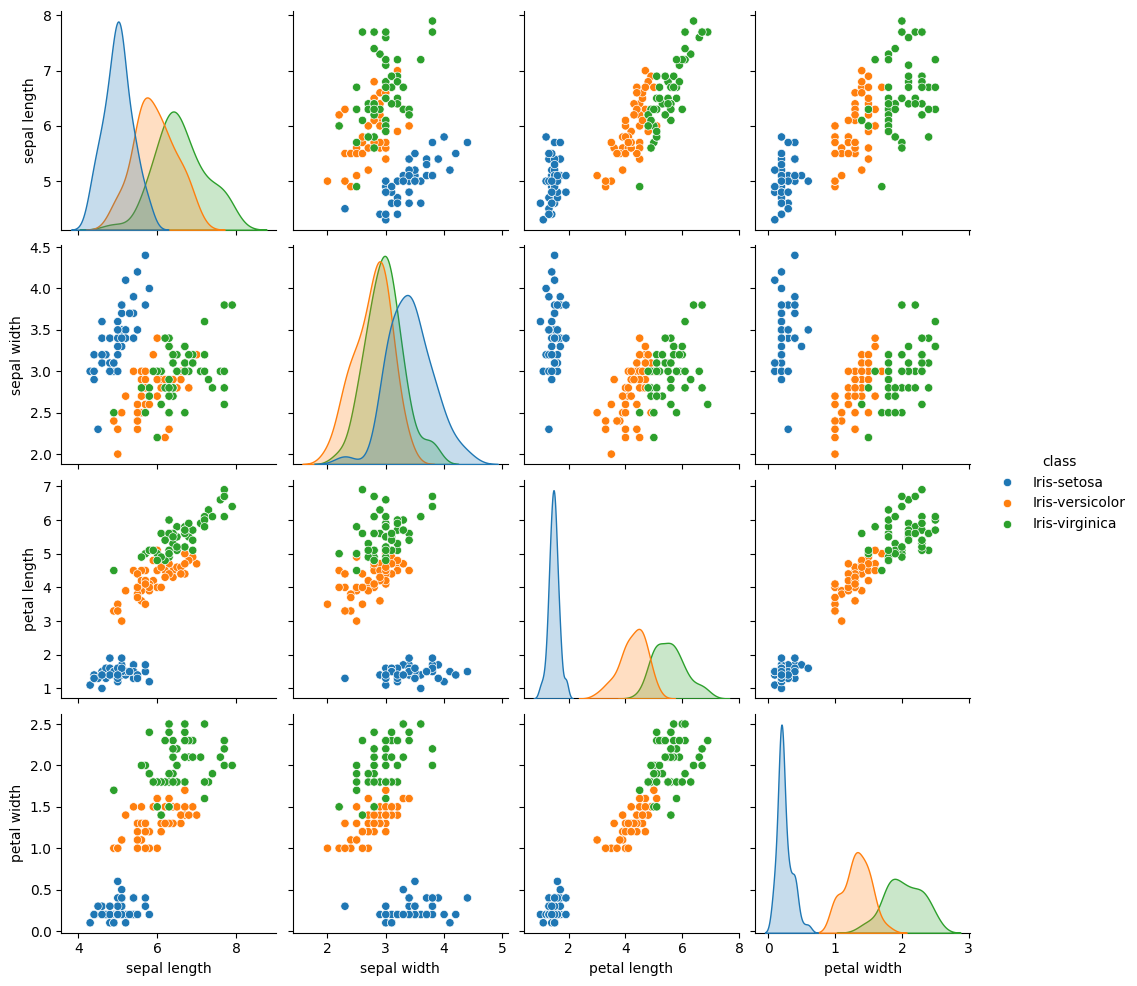

In [40]:
import seaborn as sns

sns.pairplot(pd.concat([X, y], axis=1), hue="class")
plt.show()

## 5.

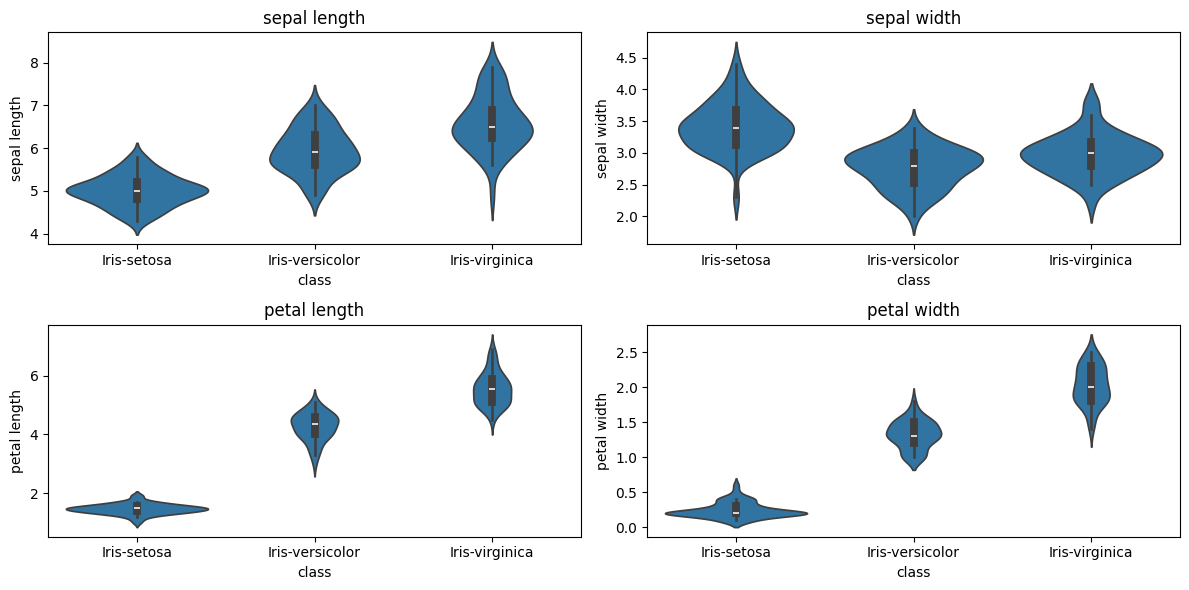

In [49]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(X.columns):
    plt.subplot(2, 2, i+1)
    sns.violinplot(x=y['class'], y=X[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Ex2

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
from ucimlrepo import fetch_ucirepo
 
#fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets

In [12]:
y.head()

,y
0,no
1,no
2,no
3,no
4,no


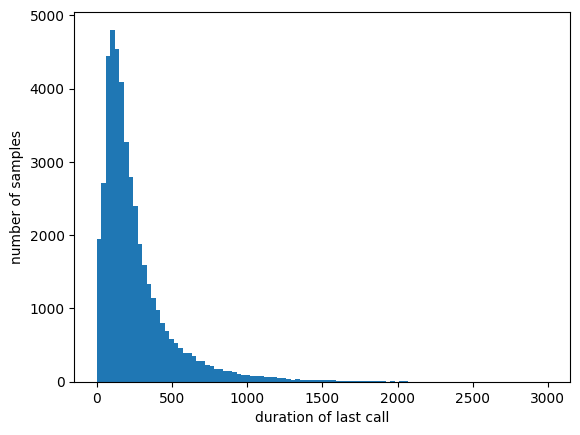

In [ ]:
balance = X["duration"]
plt.hist(balance, bins = 100, range=[0, 3000])
plt.ylabel('number of samples')
plt.xlabel('duration of last call')
plt.show()

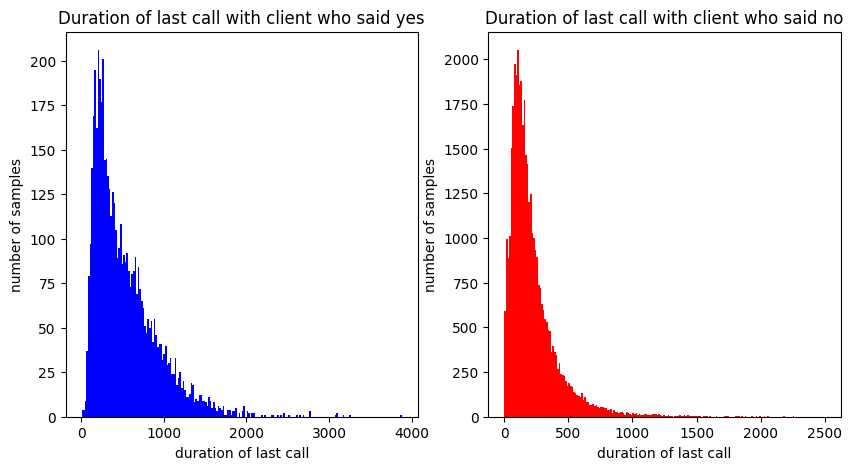

In [ ]:
mask_yes = y['y'] == 'yes'
mask_no = y['y'] == 'no'

duration_yes = balance[mask_yes]
duration_no = balance[mask_no]

n_of_bins = 200
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.hist(duration_yes, bins=n_of_bins, facecolor='blue')
plt.ylabel('number of samples')
plt.xlabel('duration of last call')
plt.title('Duration of last call with client who said yes')

plt.subplot(122)
plt.hist(duration_no, bins=n_of_bins, facecolor='r', range=[0,2500])
plt.ylabel('number of samples')
plt.xlabel('duration of last call')
plt.title('Duration of last call with client who said no')

plt.show()

### Pytanie - Co ciekawego widać na tych wykresach?
- Widzimy, że klienci, którzy zgodzili się na założenie lokaty terminowej, rozmawiali dłużej niż ci, którzy się nie zgodzili

## 2.

In [32]:
import ipywidgets
age = X['age']

def plot_hist_for_age(n : int, bin_arg):
    age_under_n = age[age < n]
    plt.hist(age_under_n, bins=bin_arg)  

ipywidgets.interact(plot_hist_for_age, n=(18, 90, 1), bin_arg=(1, 72, 1))
print("")

interactive(children=(IntSlider(value=54, description='n', max=90, min=18), IntSlider(value=36, description='b…

## 3.

In [60]:
duration = X['duration']

def calculate_positive_percent_for_call_duration(t = 360):
    mask_grater_than_t = (duration > t) & (y['y'] == 'yes')
    duration_grater_than_t = duration[mask_grater_than_t]
    positive_percent = duration_grater_than_t.shape[0] / duration.shape[0] * 100
    return positive_percent

y_d = np.arange(duration.min(), duration.max(), 10)
x_d = [calculate_positive_percent_for_call_duration(t) for t in y_d]

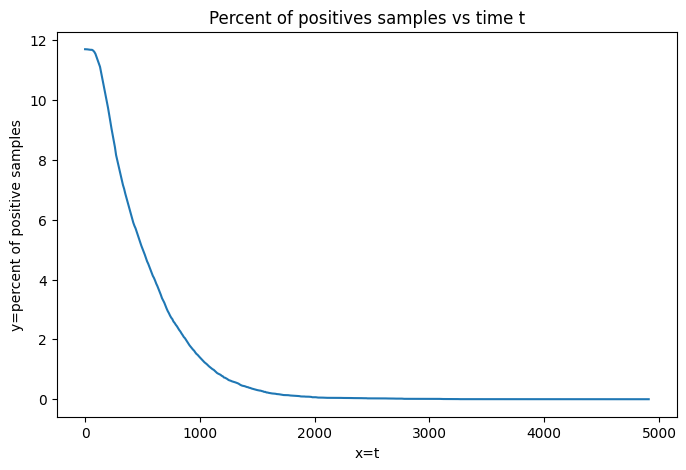

In [61]:
plt.figure(figsize=(8,5))
plt.plot(y_d, x_d)
plt.xlabel('x=t')
plt.ylabel('y=percent of positive samples')
plt.title("Percent of positives samples vs time t")
plt.show()

### Spróbuj wytłumaczyć zjawisko widoczne na wykresie.
- Na wykresie widzimy, że wraz z długością rozmowy spadał procent pozytywnych decyzji klietów o założeniu lokaty terminowej

## 4.

In [59]:
balance = X['balance']

def calculate_positive_percent_for_balance(t):
    mask_grater_than_t = (balance > t) & (y['y'] == 'yes')
    balance_grater_than_t = balance[mask_grater_than_t]
    positive_percent = balance_grater_than_t.shape[0] / balance.shape[0] * 100
    return positive_percent

y_b = np.arange(balance.min(), balance.max(), 1000)
x_b = [calculate_positive_percent_for_balance(t) for t in y_b]

In [49]:
print(balance.min(), balance.max())

-8019 102127


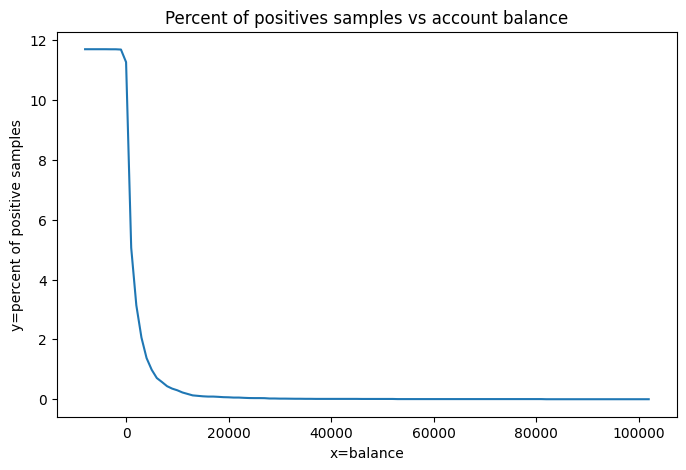

In [66]:
plt.figure(figsize=(8,5))
plt.plot(y_b, x_b)
plt.xlabel('x=balance')
plt.ylabel('y=percent of positive samples')
plt.title("Percent of positives samples vs account balance")
plt.show()

### Pytanie
Możesz kontaktować się z losowo wybranymi (z rozkładem
jednostajnym na całych danych) klientami banku, albo jedynie z klientami o saldzie (atrybut
balance) powyżej ustalonego progu (możesz sam ustalić ten próg). Która strategia jest lepsza?
Jaki próg wybrać?

  - >Z danych wynika, że lepiej jest się kontaktować z kilentami o niższym saldzie (ponieważ liczba pozytywnych decyzji spada wraz ze wzrostem salda), więc najlepiej ustawić próg = 0,
  co jest równoważne z losowym wybieraniem klientów dla całych danych

# Ex3

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [128]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
car_evaluation = fetch_ucirepo(id=19) 
  
# data (as pandas dataframes) 
X = car_evaluation.data.features 
y = car_evaluation.data.targets 

In [135]:
X[(X['safety'] == 'high') & (X['doors'] == '4')]

,buying,maint,doors,persons,lug_boot,safety
56,vhigh,vhigh,4,2,small,high
59,vhigh,vhigh,4,2,med,high
62,vhigh,vhigh,4,2,big,high
65,vhigh,vhigh,4,4,small,high
68,vhigh,vhigh,4,4,med,high
...,...,...,...,...,...,...
1688,low,low,4,4,med,high
1691,low,low,4,4,big,high
1694,low,low,4,more,small,high
1697,low,low,4,more,med,high


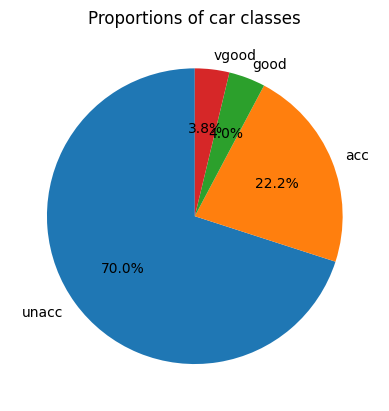

In [76]:
labels = y['class'].value_counts().index
sizes = y['class'].value_counts().values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Proportions of car classes')
plt.show()

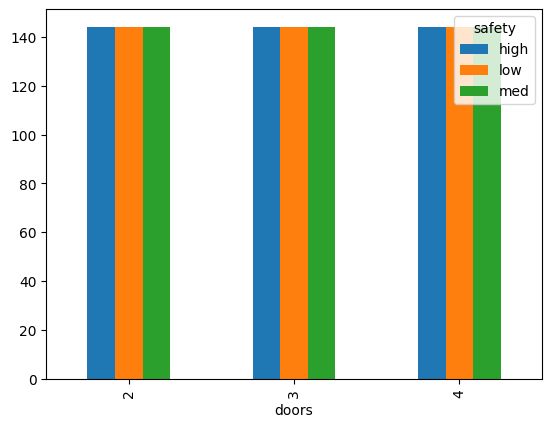

In [121]:
subset = X[['doors', 'safety']]
counts = X.groupby(['doors', 'safety']).size().unstack(fill_value=0)

counts.loc[['2', '3', '4']].plot(kind='bar')
plt.show()

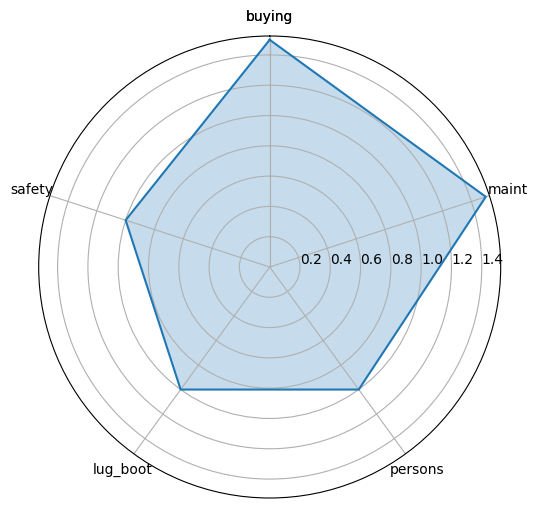

In [ ]:
car_features = X[['buying', 'maint', 'persons', 'lug_boot', 'safety']]
car_features_numeric = car_features.apply(lambda col: pd.factorize(col)[0])
car_labels = car_features.columns
values = [np.median(car_features_numeric[l]) for l in car_labels]

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': 'polar'})

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_rlabel_position(90)

theta = np.linspace(0, 2 * np.pi, len(car_labels), endpoint=False)
theta = np.concatenate([theta, [theta[0]]])
values = np.concatenate([values, [values[0]]])
plt.plot(theta, values)
plt.fill(theta, values, alpha=0.25)
plt.xticks(theta, np.concatenate([car_labels, [car_labels[0]]]))
plt.show()

# Ex 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
mu = 0
sigma = 1
X = np.random.randn(1_000_000) * sigma + mu

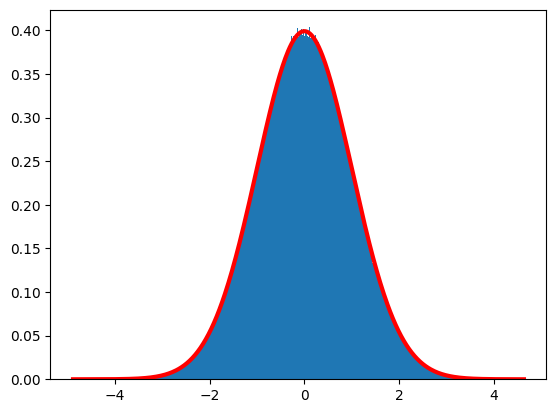

(500,) (500,)


In [3]:
from scipy.stats import norm

x = np.linspace(X.min(), X.max(), 500)
p = norm.pdf(x, mu, sigma)
plt.hist(X, bins=500, density=True)
plt.plot(x, p, 'r', linewidth=3)
plt.show()
print(x.shape, p.shape)

In [215]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets

In [200]:
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


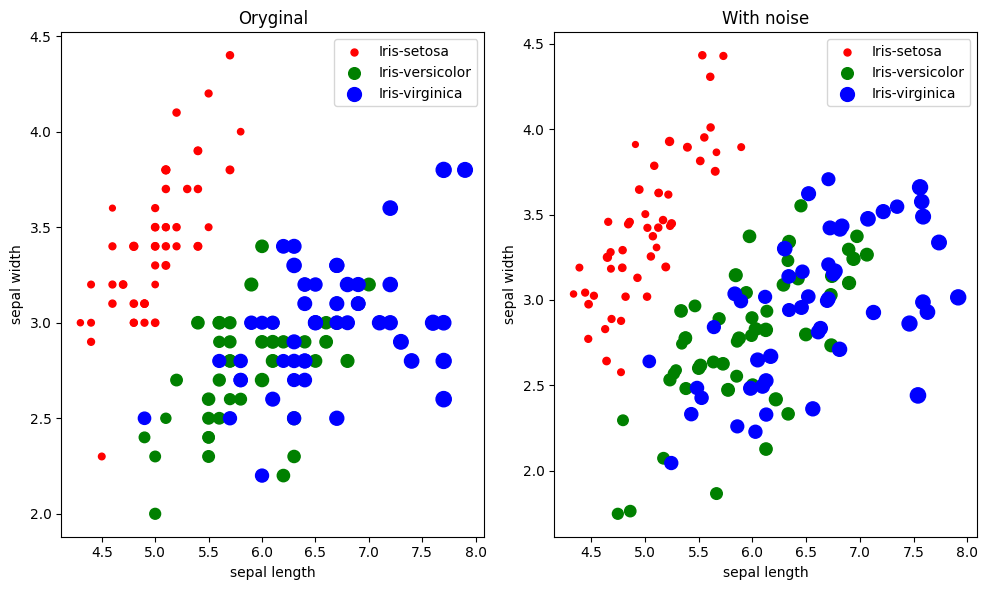

In [260]:
from matplotlib.colors import ListedColormap

colors = ["red", "green", "blue"]
classes = y["class"].unique()
my_cmap = ListedColormap(colors)


def make_scatter_plot(X: pd.DataFrame, y: pd.DataFrame, col: int, title=None):
    for i, class_name in enumerate(classes):
        mask = y["class"] == class_name
        data = {
            "x": X.loc[mask, "sepal length"],
            "y": X.loc[mask, "sepal width"],
            "color": colors[i],
            "dot_size": (X.loc[mask, "petal length"] / X["petal length"].max()) * 120,
        }
        plt.subplot(1, 2, col)
        plt.scatter(x="x", y="y", s="dot_size", c="color", label=class_name, data=data)
        plt.xlabel("sepal length")
        plt.ylabel("sepal width")
        plt.title(title)
        plt.legend()


sepal_length_width = X[["sepal length", "sepal width"]]
noise = np.random.normal(loc=0, scale=0.25, size=sepal_length_width.shape[0])

X_cp = X.copy()
X_cp[["sepal length", "sepal width"]] = sepal_length_width.apply(
    lambda col: col + noise
)

plt.figure(figsize=(10, 6))
make_scatter_plot(X=X, y=y, col=1, title="Oryginal")
make_scatter_plot(X=X_cp, y=y, col=2, title="With noise")
plt.tight_layout()
plt.show()

Czy zaproponowana przez Ciebie reguła odróżniania iris setosa
nadal działa?

- >Dla s = 0.25, tak, bo zaburzenie nie wpłyneło na tyle mocno aby iris-setosa nie miał najmniejszgo stosunku sepal length do sepal width

# Ex 5

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal
import plotly.graph_objects as go

In [24]:
mu = [0, 0]
cov = np.array([
    [1, 0.0],
    [0.0, 1]
])

samples = np.random.randn(500_000, 2) @ cov + mu

hist, xedges, yedges = np.histogram2d(samples[:, 0], samples[:, 1], bins=100, density=True)
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1])

X, y = np.meshgrid(np.linspace(-4, 4, 100), np.linspace(-4, 4, 100))
pos = np.dstack((X, y))
rv = multivariate_normal(mu, cov)
Z = rv.pdf(pos)

fig = go.Figure()

fig.add_trace(go.Surface(
    x=xpos, y=ypos, z=hist.T, opacity=0.75, colorscale='deep'
))

fig.add_trace(go.Surface(
    x=X, y=y, z=Z,
    colorscale='Reds',
    opacity=0.6,
    name='Density'
))

fig.update_layout(
    scene=dict(
        zaxis_title='density'
    )
)
fig.show()